In [1]:
from tensorflow import keras
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import tensorflow_addons as tfa

np.random.seed(123)

In [2]:
def readucr(filename):
    data = np.loadtxt(filename, delimiter="\t")
    y = data[:, 0]
    x = data[:, 1:]
    return x, y.astype(int)

x_train, y_train = readucr("FordA_TRAIN.tsv")
x_test, y_test = readucr("FordA_TEST.tsv")

In [3]:
x_train = x_train.reshape((x_train.shape[0], x_train.shape[1], 1))
x_test = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))

print(x_train.shape)

(3601, 500, 1)
(3601, 500, 1)


In [4]:
y_train[y_train==-1] = 0
y_test[y_test==-1] = 0

In [5]:
print(y_train[:10])

[0 1 0 0 0 1 1 1 1 1]
[0 1 0 0 0 1 1 1 1 1]


In [6]:
idx = np.random.permutation(len(x_train))
x_train = x_train[idx]
y_train = y_train[idx]

In [7]:
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train)).batch(32)
train_ds = train_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

## Build a model

In [8]:
input_layer = keras.layers.Input((500, 1))

x = keras.layers.Conv1D(filters=64, kernel_size=3, padding="same")(input_layer)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.ReLU()(x)

x = keras.layers.Conv1D(filters=64, kernel_size=3, padding="same")(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.ReLU()(x)

x = keras.layers.Conv1D(filters=64, kernel_size=3, padding="same")(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.ReLU()(x)

x = keras.layers.GlobalAveragePooling1D()(x)
x = keras.layers.Dense(1, activation="sigmoid")(x)

model = keras.models.Model(inputs=input_layer, outputs=x)
model.summary()

Model: "model"
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 500, 1)]          0         
                                                                 
 conv1d (Conv1D)             (None, 500, 64)           256       
                                                                 
 input_1 (InputLayer)        [(None, 500, 1)]          0         
                                                                 
 conv1d (Conv1D)             (None, 500, 64)           256       
                                                                 
 batch_normalization (BatchN  (None, 500, 64)          256       
 ormalization)                                                   
                                              

## Train the model

In [9]:
epochs = 150
batch_size = 64

loss_func = tfa.losses.SigmoidFocalCrossEntropy(alpha=0.5, gamma=3.0)
model.compile(optimizer="adam",
              loss=loss_func,
              metrics=["accuracy"])
history = model.fit(train_ds,
                    batch_size=batch_size,
                    epochs=epochs,
                    validation_data=(x_test, y_test),
                    verbose=2)

Epoch 1/150
Epoch 1/150
113/113 - 28s - loss: 0.0336 - accuracy: 0.7154 - val_loss: 0.0478 - val_accuracy: 0.4841 - 28s/epoch - 244ms/step
113/113 - 28s - loss: 0.0336 - accuracy: 0.7154 - val_loss: 0.0478 - val_accuracy: 0.4841 - 28s/epoch - 244ms/step
Epoch 2/150
Epoch 2/150
113/113 - 18s - loss: 0.0289 - accuracy: 0.7728 - val_loss: 0.0604 - val_accuracy: 0.4841 - 18s/epoch - 157ms/step
113/113 - 18s - loss: 0.0289 - accuracy: 0.7728 - val_loss: 0.0604 - val_accuracy: 0.4841 - 18s/epoch - 157ms/step
Epoch 3/150
Epoch 3/150
113/113 - 18s - loss: 0.0273 - accuracy: 0.7826 - val_loss: 0.0640 - val_accuracy: 0.4841 - 18s/epoch - 159ms/step
113/113 - 18s - loss: 0.0273 - accuracy: 0.7826 - val_loss: 0.0640 - val_accuracy: 0.4841 - 18s/epoch - 159ms/step
Epoch 4/150
Epoch 4/150
113/113 - 17s - loss: 0.0266 - accuracy: 0.7931 - val_loss: 0.0629 - val_accuracy: 0.4864 - 17s/epoch - 152ms/step
113/113 - 17s - loss: 0.0266 - accuracy: 0.7931 - val_loss: 0.0629 - val_accuracy: 0.4864 - 17s/epo

113/113 - 18s - loss: 0.0155 - accuracy: 0.9059 - val_loss: 0.0202 - val_accuracy: 0.8727 - 18s/epoch - 158ms/step
113/113 - 18s - loss: 0.0155 - accuracy: 0.9059 - val_loss: 0.0202 - val_accuracy: 0.8727 - 18s/epoch - 158ms/step
Epoch 34/150
Epoch 34/150
113/113 - 18s - loss: 0.0156 - accuracy: 0.9059 - val_loss: 0.0568 - val_accuracy: 0.6273 - 18s/epoch - 158ms/step
113/113 - 18s - loss: 0.0156 - accuracy: 0.9059 - val_loss: 0.0568 - val_accuracy: 0.6273 - 18s/epoch - 158ms/step
Epoch 35/150
Epoch 35/150
113/113 - 18s - loss: 0.0151 - accuracy: 0.9086 - val_loss: 0.0960 - val_accuracy: 0.6364 - 18s/epoch - 157ms/step
113/113 - 18s - loss: 0.0151 - accuracy: 0.9086 - val_loss: 0.0960 - val_accuracy: 0.6364 - 18s/epoch - 157ms/step
Epoch 36/150
Epoch 36/150
113/113 - 18s - loss: 0.0149 - accuracy: 0.9078 - val_loss: 0.0581 - val_accuracy: 0.7061 - 18s/epoch - 159ms/step
113/113 - 18s - loss: 0.0149 - accuracy: 0.9078 - val_loss: 0.0581 - val_accuracy: 0.7061 - 18s/epoch - 159ms/step
Ep

113/113 - 18s - loss: 0.0075 - accuracy: 0.9606 - val_loss: 0.0135 - val_accuracy: 0.9197 - 18s/epoch - 157ms/step
Epoch 66/150
Epoch 66/150
113/113 - 18s - loss: 0.0071 - accuracy: 0.9639 - val_loss: 0.1709 - val_accuracy: 0.6841 - 18s/epoch - 157ms/step
113/113 - 18s - loss: 0.0071 - accuracy: 0.9639 - val_loss: 0.1709 - val_accuracy: 0.6841 - 18s/epoch - 157ms/step
Epoch 67/150
Epoch 67/150
113/113 - 18s - loss: 0.0075 - accuracy: 0.9603 - val_loss: 0.0606 - val_accuracy: 0.7326 - 18s/epoch - 158ms/step
113/113 - 18s - loss: 0.0075 - accuracy: 0.9603 - val_loss: 0.0606 - val_accuracy: 0.7326 - 18s/epoch - 158ms/step
Epoch 68/150
Epoch 68/150
113/113 - 18s - loss: 0.0072 - accuracy: 0.9633 - val_loss: 0.0089 - val_accuracy: 0.9598 - 18s/epoch - 158ms/step
113/113 - 18s - loss: 0.0072 - accuracy: 0.9633 - val_loss: 0.0089 - val_accuracy: 0.9598 - 18s/epoch - 158ms/step
Epoch 69/150
Epoch 69/150
113/113 - 18s - loss: 0.0071 - accuracy: 0.9620 - val_loss: 0.0083 - val_accuracy: 0.9659 -

Epoch 98/150
Epoch 98/150
113/113 - 18s - loss: 0.0057 - accuracy: 0.9700 - val_loss: 0.0082 - val_accuracy: 0.9652 - 18s/epoch - 157ms/step
113/113 - 18s - loss: 0.0057 - accuracy: 0.9700 - val_loss: 0.0082 - val_accuracy: 0.9652 - 18s/epoch - 157ms/step
Epoch 99/150
Epoch 99/150
113/113 - 18s - loss: 0.0060 - accuracy: 0.9708 - val_loss: 0.0274 - val_accuracy: 0.8500 - 18s/epoch - 159ms/step
113/113 - 18s - loss: 0.0060 - accuracy: 0.9708 - val_loss: 0.0274 - val_accuracy: 0.8500 - 18s/epoch - 159ms/step
Epoch 100/150
Epoch 100/150
113/113 - 18s - loss: 0.0061 - accuracy: 0.9681 - val_loss: 0.0604 - val_accuracy: 0.7659 - 18s/epoch - 157ms/step
113/113 - 18s - loss: 0.0061 - accuracy: 0.9681 - val_loss: 0.0604 - val_accuracy: 0.7659 - 18s/epoch - 157ms/step
Epoch 101/150
Epoch 101/150
113/113 - 18s - loss: 0.0057 - accuracy: 0.9683 - val_loss: 0.0856 - val_accuracy: 0.6765 - 18s/epoch - 157ms/step
113/113 - 18s - loss: 0.0057 - accuracy: 0.9683 - val_loss: 0.0856 - val_accuracy: 0.67

Epoch 130/150
Epoch 130/150
113/113 - 18s - loss: 0.0050 - accuracy: 0.9739 - val_loss: 0.0100 - val_accuracy: 0.9447 - 18s/epoch - 156ms/step
113/113 - 18s - loss: 0.0050 - accuracy: 0.9739 - val_loss: 0.0100 - val_accuracy: 0.9447 - 18s/epoch - 156ms/step
Epoch 131/150
Epoch 131/150
113/113 - 18s - loss: 0.0050 - accuracy: 0.9722 - val_loss: 0.0078 - val_accuracy: 0.9606 - 18s/epoch - 156ms/step
113/113 - 18s - loss: 0.0050 - accuracy: 0.9722 - val_loss: 0.0078 - val_accuracy: 0.9606 - 18s/epoch - 156ms/step
Epoch 132/150
Epoch 132/150
113/113 - 18s - loss: 0.0049 - accuracy: 0.9753 - val_loss: 0.0579 - val_accuracy: 0.7985 - 18s/epoch - 156ms/step
113/113 - 18s - loss: 0.0049 - accuracy: 0.9753 - val_loss: 0.0579 - val_accuracy: 0.7985 - 18s/epoch - 156ms/step
Epoch 133/150
Epoch 133/150
113/113 - 18s - loss: 0.0046 - accuracy: 0.9747 - val_loss: 0.0566 - val_accuracy: 0.7697 - 18s/epoch - 156ms/step
113/113 - 18s - loss: 0.0046 - accuracy: 0.9747 - val_loss: 0.0566 - val_accuracy: 

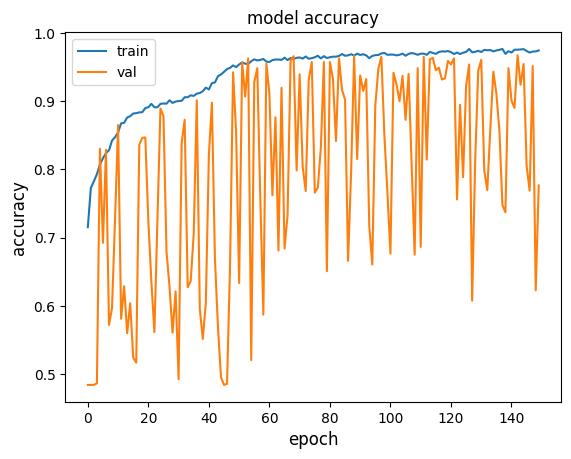

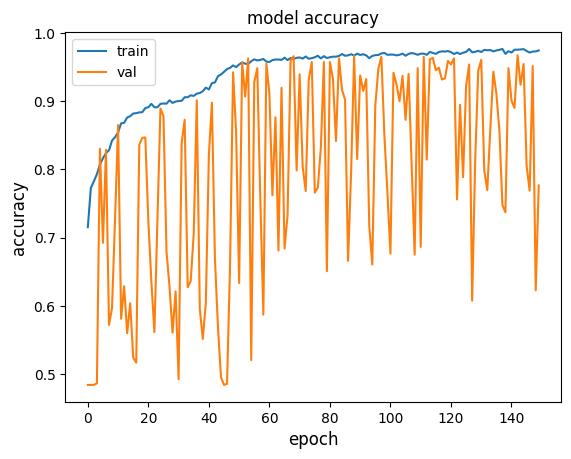

In [10]:
metric = "accuracy"
plt.figure()
plt.plot(history.history[metric])
plt.plot(history.history["val_" + metric])
plt.title("model " + metric)
plt.ylabel(metric, fontsize="large")
plt.xlabel("epoch", fontsize="large")
plt.legend(["train", "val"], loc="best")
plt.show()
plt.close()